# ETF 净申购批次收益分析

当前清单包含 180 只 ETF，分为 11 个分类：7 个宽基或策略指数与 4 个行业分类。每只 ETF 独立识别正净申购、调整份额拆分并计算收益，再按申购金额汇总到所属分类。收益使用单位净值与税前、已到账且不再投资的现金分红计算；不计税费和交易费用。

In [1]:
import os
import sys
import tempfile
from pathlib import Path
from textwrap import fill

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'mme').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'mme-matplotlib'))

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

from mme.subscription.profitability import calculate_etf_profitability

chinese_font_candidates = ['PingFang SC', 'Heiti SC', 'Hiragino Sans GB', 'STHeiti']
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((font for font in chinese_font_candidates if font in installed_fonts), None)
if chinese_font is None:
    raise RuntimeError('未找到可用中文字体，请安装 PingFang SC、Heiti SC 或 Hiragino Sans GB 后重试。')

plt.rcParams['font.sans-serif'] = [chinese_font]
plt.rcParams['axes.unicode_minus'] = False
print(f'使用中文字体：{chinese_font}')

Matplotlib is building the font cache; this may take a moment.


使用中文字体：PingFang SC


In [2]:
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
shares_path = ROOT / 'data/source/subscription/etf_shares.parquet'
nav_path = ROOT / 'data/source/subscription/etf_nav.parquet'
splits_path = ROOT / 'data/source/subscription/etf_splits.parquet'
dividends_path = ROOT / 'data/source/subscription/etf_dividends.parquet'
universe_path = ROOT / 'config/etf_universe.csv'
requested_as_of_date = None  # Example: '2026-06-30'

In [3]:
result = calculate_etf_profitability(
    shares_path, nav_path, splits_path, dividends_path, universe_path, requested_as_of_date,
)
as_of_date = result.as_of_date
universe = result.universe
fund_name_map = result.fund_name_map
summary = result.summary
index_daily_batches = result.index_daily_batches

In [4]:
print(f'实际评价日：{as_of_date}')

if result.split_adjustments.empty:
    print('分析区间内未发现需要调整的拆分记录。')
else:
    split_review = result.split_adjustments.assign(基金简称=lambda data: data['fund_code'].map(fund_name_map)).loc[:, ['基金简称', 'split_date', 'split_type', 'split_ratio', 'previous_total_shares', 'total_shares', 'unadjusted_share_change', 'net_subscription_shares']].rename(columns={'split_date': '拆分日期', 'split_type': '拆分类型', 'split_ratio': '折算比例', 'previous_total_shares': '拆分前份额', 'total_shares': '拆分后份额', 'unadjusted_share_change': '未调整份额变化', 'net_subscription_shares': '调整后净申购份额'})
    split_review['折算比例'] = split_review['折算比例'].map(lambda ratio: f'1:{ratio:.4f}')
    print('发现份额拆分并已自动调整，请人工复核：')
    display(split_review.style.hide(axis='index').format({'拆分前份额': '{:,.0f}', '拆分后份额': '{:,.0f}', '未调整份额变化': '{:,.0f}', '调整后净申购份额': '{:,.0f}'}))

if result.dividend_events.empty:
    print('截至评价日，没有已计入收益的现金分红。')
else:
    dividend_review = result.dividend_events.groupby(['fund_code', 'record_date', 'ex_date', 'payment_date', 'cash_dividend_per_share'], as_index=False).agg(适用申购批次数=('batch_id', 'nunique')).assign(基金简称=lambda data: data['fund_code'].map(fund_name_map)).loc[:, ['基金简称', 'record_date', 'ex_date', 'payment_date', 'cash_dividend_per_share', '适用申购批次数']].rename(columns={'record_date': '权益登记日', 'ex_date': '除息日', 'payment_date': '发放日', 'cash_dividend_per_share': '每份现金分红'})
    print('截至评价日已计入收益的现金分红复核表：')
    display(dividend_review.style.hide(axis='index').format({'每份现金分红': '{:.6f}'}))

component_review = universe.groupby(['index_name', 'index_order'], as_index=False).agg(etf_count=('fund_code', 'size'), etf_components=('fund_name', lambda values: '、'.join(values))).sort_values('index_order').loc[:, ['index_name', 'etf_count', 'etf_components']].rename(columns={'index_name': '分类名称', 'etf_count': 'ETF数量', 'etf_components': 'ETF成分'})
print('11 个分类的 ETF 成分复核表：')
display(component_review.style.hide(axis='index'))

display_summary = summary.loc[:, ['index_name', 'subscription_amount', 'completed_60_trade_day_subscription_amount', 'profitable_amount_60_trade_days', 'profitable_capital_ratio_60_trade_days', 'profitable_amount_to_date', 'profitable_capital_ratio_to_date', 'subscription_batches', 'completed_60_trade_day_batches', 'completed_60_trade_day_batch_ratio']].rename(columns={'index_name': '分类名称', 'subscription_amount': '全部正净申购金额', 'completed_60_trade_day_subscription_amount': '已满60交易日申购金额', 'profitable_amount_60_trade_days': '完整60交易日赚钱资金金额', 'profitable_capital_ratio_60_trade_days': '完整60交易日赚钱资金比例', 'profitable_amount_to_date': '截至评价日赚钱资金金额', 'profitable_capital_ratio_to_date': '截至评价日赚钱资金比例', 'subscription_batches': '全部申购批次数', 'completed_60_trade_day_batches': '已满60交易日批次数', 'completed_60_trade_day_batch_ratio': '60交易日批次完成率'})
display(display_summary.style.hide(axis='index').format({'全部正净申购金额': '{:,.0f}', '已满60交易日申购金额': '{:,.0f}', '完整60交易日赚钱资金金额': '{:,.0f}', '截至评价日赚钱资金金额': '{:,.0f}', '完整60交易日赚钱资金比例': '{:.1%}', '截至评价日赚钱资金比例': '{:.1%}', '60交易日批次完成率': '{:.1%}'}, na_rep='—'))

实际评价日：2026-07-24
发现份额拆分并已自动调整，请人工复核：


基金简称,拆分日期,拆分类型,折算比例,拆分前份额,拆分后份额,未调整份额变化,调整后净申购份额
半导体设备ETF万家,2026-07-17,份额分拆,1:3.0000,"688,524,697","1,984,574,091","1,296,049,394","-81,000,000"
半导体设备ETF国泰,2026-03-27,份额分拆,1:2.0000,"12,008,589,993","23,571,179,986","11,562,589,993","-446,000,000"
半导体设备ETF国泰,2026-07-09,份额分拆,1:2.0000,"24,569,179,986","51,770,359,972","27,201,179,986","2,632,000,000"
半导体设备ETF易方达,2026-07-08,份额分拆,1:3.0000,"4,334,854,641","12,728,563,923","8,393,709,282","-276,000,000"
半导体ETF博时,2026-07-10,份额分拆,1:5.0000,"151,621,621","855,608,105","703,986,484","97,500,000"
有色ETF银华,2026-02-06,份额分拆,1:2.0000,"444,866,253","872,732,506","427,866,253","-17,000,000"
有色金属ETF国泰,2026-06-25,份额分拆,1:2.0000,"89,249,583","178,499,166","89,249,583",0
芯片ETF华夏,2026-07-06,份额分拆,1:2.0000,"11,259,963,006","22,391,126,012","11,131,163,006","-128,800,000"
广发上证50ETF,2026-04-24,份额分拆,1:1.2877,"79,200,000","101,020,800","21,820,800","-965,040"
半导体ETF国联安,2026-07-02,份额分拆,1:2.0000,"8,689,003,600","17,366,007,200","8,677,003,600","-12,000,000"


截至评价日已计入收益的现金分红复核表：


基金简称,权益登记日,除息日,发放日,每份现金分红,适用申购批次数
华夏红利低波ETF,2026-06-12,2026-06-15,2026-06-17,0.012000,64
华泰柏瑞沪深300ETF,2026-01-16,2026-01-19,2026-01-27,0.123000,3
易方达沪深300ETF,2026-01-20,2026-01-20,2026-01-21,0.075000,2
南方中证500ETF,2026-01-15,2026-01-16,2026-01-21,0.062000,4
南方中证500ETF,2026-07-14,2026-07-15,2026-07-20,0.149000,53
南方中证1000ETF,2026-01-16,2026-01-19,2026-01-22,0.041000,4
泰康红利低波ETF,2026-04-20,2026-04-21,2026-04-24,0.007000,8
泰康红利低波ETF,2026-07-20,2026-07-21,2026-07-24,0.006700,16
易方达红利低波ETF,2026-03-10,2026-03-11,2026-03-16,0.012000,35
易方达红利低波ETF,2026-06-09,2026-06-10,2026-06-15,0.012000,88


11 个分类的 ETF 成分复核表：


分类名称,ETF数量,ETF成分
上证50,11,华夏上证50ETF、易方达上证50ETF、华安上证50ETF、申万菱信上证50ETF、万家上证50ETF、博时上证50ETF、建信上证50ETF、工银上证50ETF、广发上证50ETF、天弘上证50ETF、东财上证50ETF
沪深300,25,富国沪深300ETF、东财沪深300ETF、万家沪深300ETF、鹏华沪深300ETF、嘉实沪深300ETF、南方沪深300ETF、华泰柏瑞沪深300ETF、易方达沪深300ETF、中金沪深300ETF、华夏沪深300ETF、工银沪深300ETF、广发沪深300ETF、兴业沪深300ETF、国寿沪深300ETF、平安沪深300ETF、博时沪深300ETF、汇添富沪深300ETF、天弘沪深300ETF、民生加银沪深300ETF、方正富邦沪深300ETF、泰康沪深300ETF、华安沪深300ETF、国联安沪深300ETF、招商沪深300ETF、永赢沪深300ETF
中证500,22,东财中证500ETF、富国中证500ETF、天弘中证500ETF、嘉实中证500ETF、景顺长城中证500ETF、博时中证500ETF、鹏华中证500ETF、南方中证500ETF、广发中证500ETF、工银中证500ETF、方正富邦中证500ETF、国寿中证500ETF、兴业中证500ETF、易方达中证500ETF、平安中证500ETF、华夏中证500ETF、华泰柏瑞中证500ETF、中银证券中证500ETF、泰康中证500ETF、国联中证500ETF、国泰中证500ETF、汇添富中证500ETF
中证1000,7,富国中证1000ETF、易方达中证1000ETF、华夏中证1000ETF、南方中证1000ETF、华泰柏瑞中证1000ETF、广发中证1000ETF、汇添富中证1000ETF
中证2000,10,南方中证2000ETF、易方达中证2000ETF、博时中证2000ETF、嘉实中证2000ETF、汇添富中证2000ETF、广发中证2000ETF、国泰中证2000ETF、华夏中证2000ETF、富国中证2000ETF、华泰柏瑞中证2000ETF
红利低波,8,富国红利低波ETF、华夏红利低波ETF、天弘红利低波ETF、华泰柏瑞红利低波ETF、泰康红利低波ETF、国泰海通红利低波ETF、易方达红利低波ETF、永赢红利低波ETF
科创50,17,华夏科创50ETF、鹏华科创50ETF、工银科创50ETF、广发科创50ETF、易方达科创50ETF、华泰柏瑞科创50ETF、南方科创50ETF、国联安科创50ETF、华安科创50ETF、中银科创50ETF、万家科创50ETF、汇添富科创50ETF、富国科创50ETF、景顺长城科创50ETF、平安科创50ETF、国泰科创50ETF、东财科创50ETF
半导体,18,半导体ETF南方、半导体设备ETF万家、半导体设备ETF国泰、半导体设备ETF易方达、半导体ETF博时、半导体龙头ETF工银、芯片ETF广发、半导体ETF鹏华、芯片ETF华夏、半导体ETF国联安、芯片ETF国泰、中韩半导体ETF华泰柏瑞、半导体设备ETF广发、半导体设备ETF招商、半导体设备ETF华夏、科创半导体ETF华夏、科创半导体设备ETF华泰柏瑞、科创半导体设备ETF鹏华
有色金属,25,广发中证有色金属矿业主题ETF、工业有色ETF易方达、有色ETF工银、有色金属ETF天弘、工业有色ETF鹏华、有色ETF泰康、有色ETF富国、工业有色ETF博时、有色ETF汇添富、有色矿业ETF招商、有色ETF银华、有色ETF华宝、有色ETF鹏华、有色金属ETF国泰、有色ETF大成、有色金属ETF南方、有色ETF华安、有色金属ETF华夏、有色ETF景顺、有色ETF易方达、工业有色ETF华泰柏瑞、工业有色ETF万家、工业有色ETF中银、工业有色ETF平安、矿业ETF国泰
电力,23,绿电ETF天弘、绿色电力ETF南方、鹏华国证绿色电力ETF、电力ETF华宝、电力ETF景顺、电力ETF广发、绿色电力ETF嘉实、绿色电力ETF国泰、电力ETF华安、电力ETF汇添富、电力ETF工银、电力ETF天弘、电力ETF平安、电力ETF招商、电力ETF南方、电力ETF华夏、电力ETF易方达、绿色电力ETF富国、电力ETF华泰柏瑞、电力ETF博时、电力ETF银华、绿电ETF华夏、绿色电力ETF易方达


分类名称,全部正净申购金额,已满60交易日申购金额,完整60交易日赚钱资金金额,完整60交易日赚钱资金比例,截至评价日赚钱资金金额,截至评价日赚钱资金比例,全部申购批次数,已满60交易日批次数,60交易日批次完成率
上证50,"35,785,899,205","15,147,218,865","6,205,310,930",41.0%,"27,072,306,910",75.7%,346,173,50.0%
沪深300,"120,272,760,990","35,162,562,300","30,578,898,280",87.0%,"63,983,392,800",53.2%,754,325,43.1%
中证500,"100,643,168,420","51,353,662,980","43,431,987,230",84.6%,"8,755,796,210",8.7%,644,353,54.8%
中证1000,"127,947,367,200","36,057,792,600","30,562,014,300",84.8%,"3,633,098,300",2.8%,337,152,45.1%
中证2000,"13,546,164,500","5,610,815,250","4,586,316,700",81.7%,"167,899,300",1.2%,279,133,47.7%
红利低波,"25,514,093,000","11,945,928,350","5,048,016,950",42.3%,"13,761,574,650",53.9%,432,205,47.5%
科创50,"100,721,650,150","28,563,899,100","24,079,667,050",84.3%,"62,201,376,250",61.8%,702,317,45.2%
半导体,"198,364,973,421","48,976,630,861","27,572,582,101",56.3%,"20,567,044,221",10.4%,1120,577,51.5%
有色金属,"82,199,078,829","63,935,711,440","16,591,964,360",26.0%,"510,873,230",0.6%,1024,495,48.3%
电力,"27,624,256,030","13,303,205,350","3,898,233,380",29.3%,"2,804,626,390",10.2%,939,406,43.2%


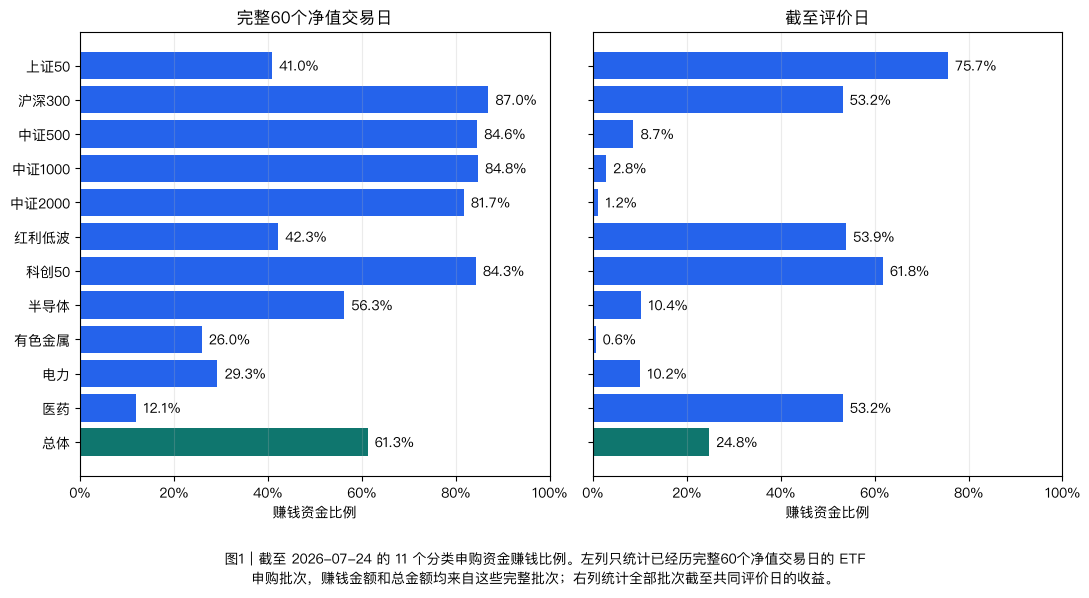

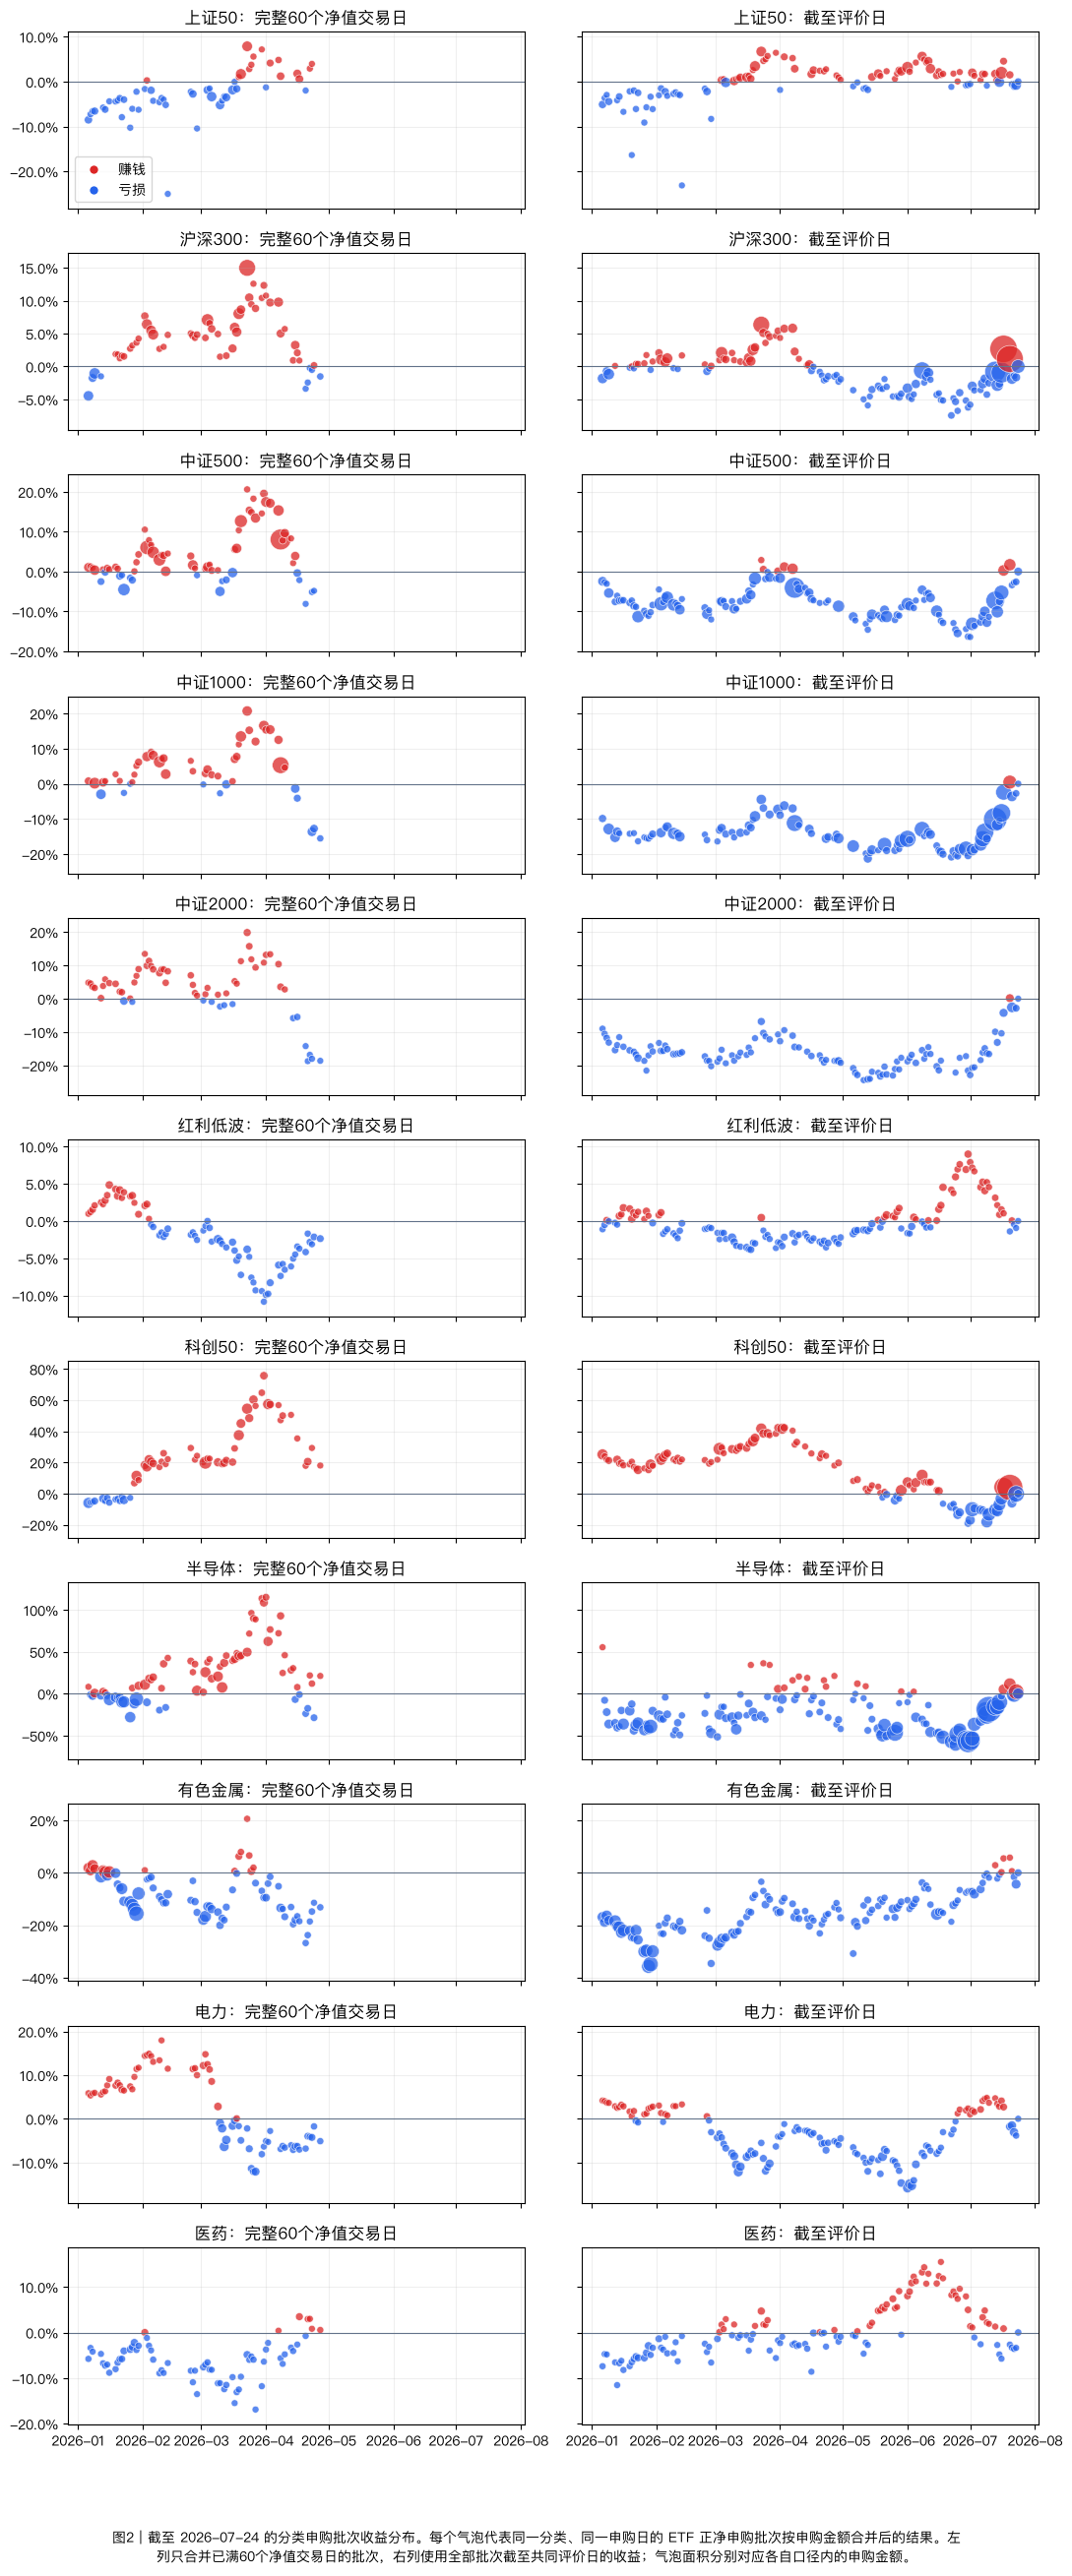

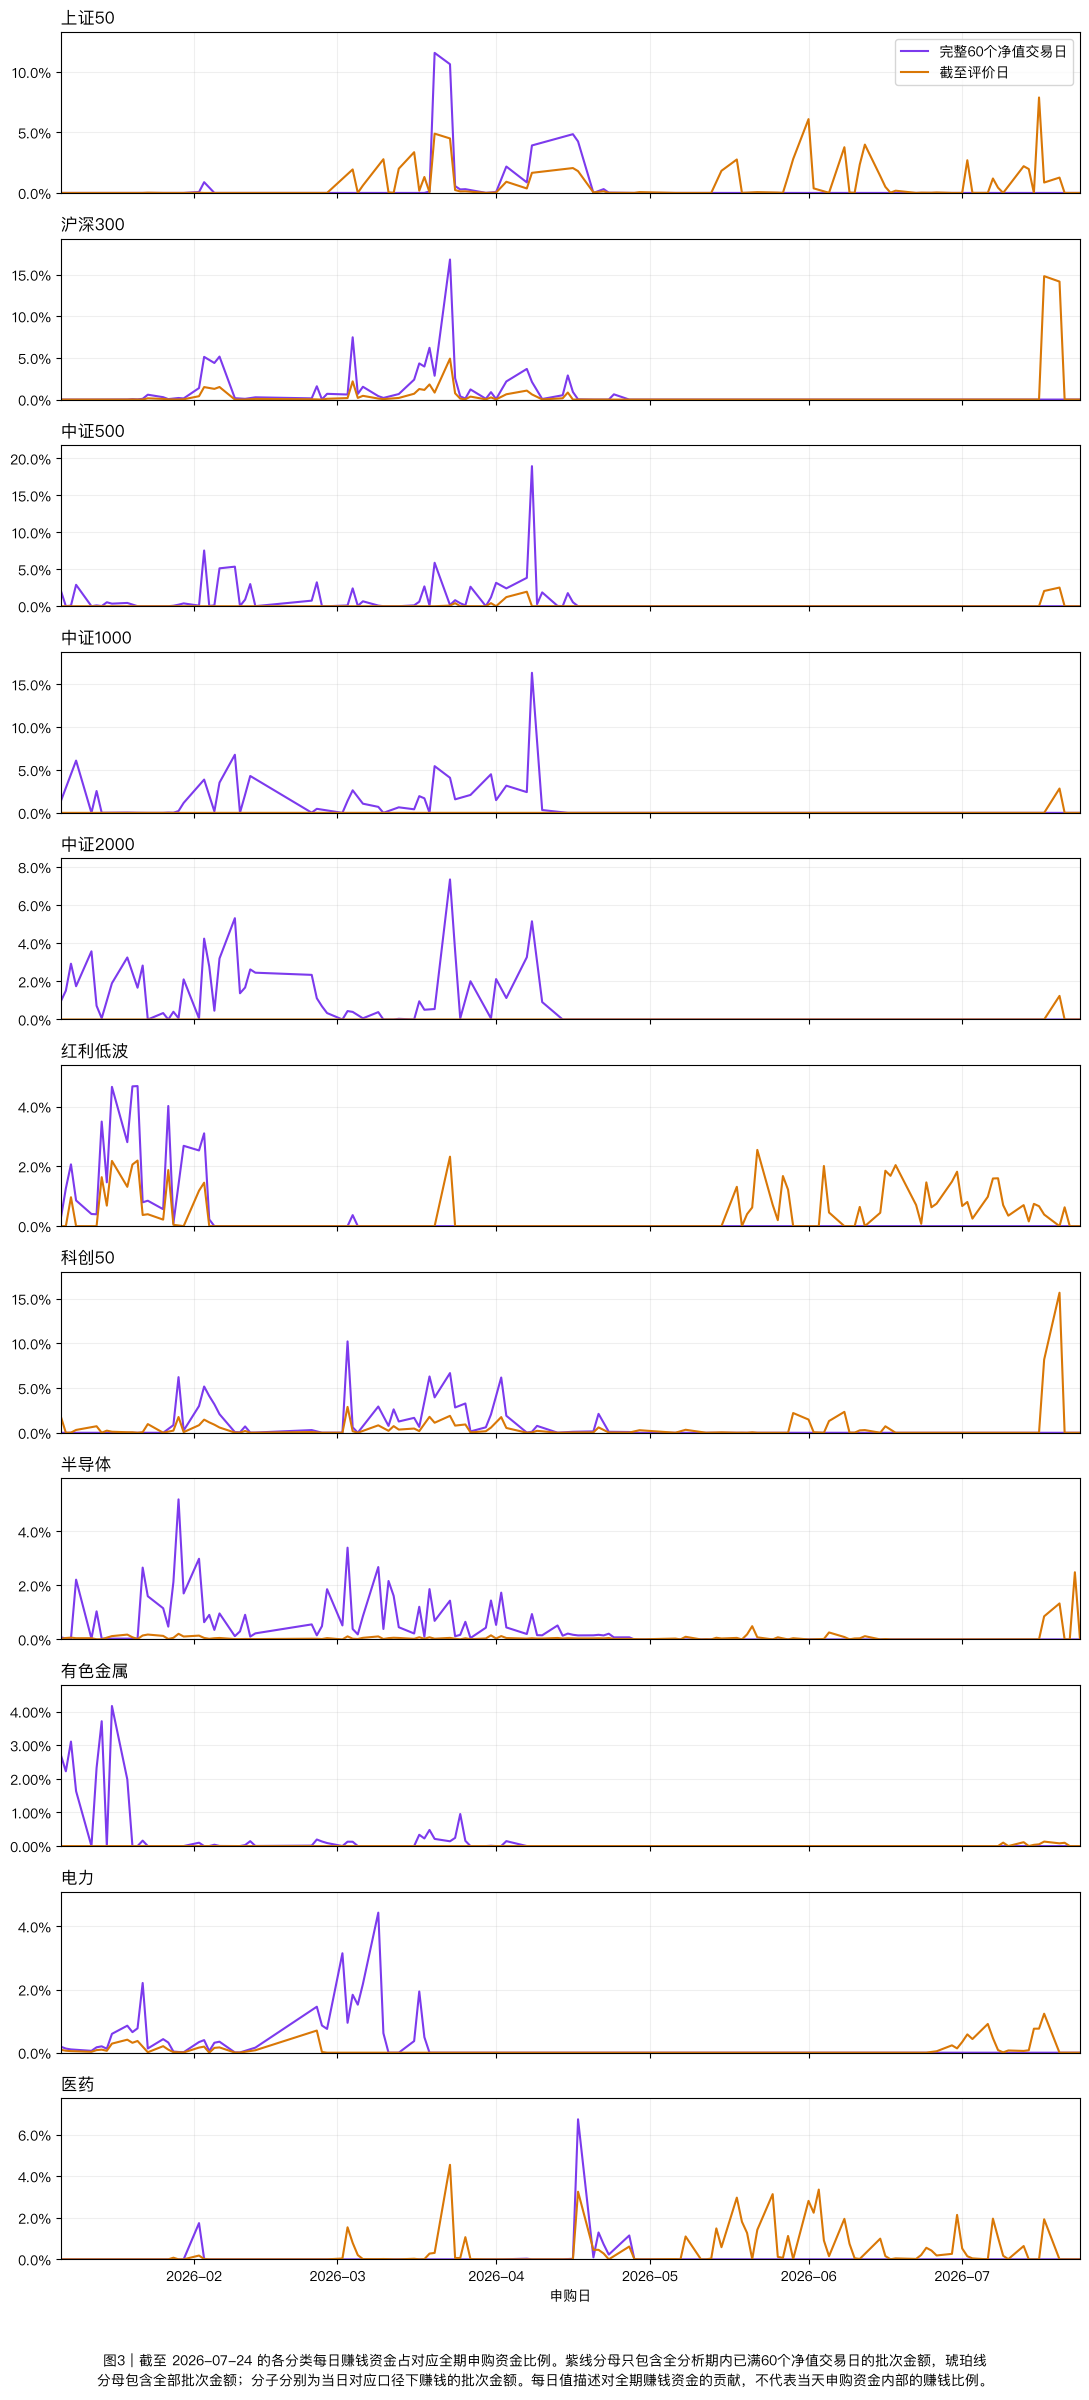

In [5]:
labels = summary['index_name']
bar_colors = ['#0F766E' if code == 'ALL' else '#2563EB' for code in summary['index_code']]
ratio_panels = [('profitable_capital_ratio_60_trade_days', '完整60个净值交易日'), ('profitable_capital_ratio_to_date', '截至评价日')]
figure, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)
for axis, (ratio_column, title) in zip(axes, ratio_panels):
    ratios = summary[ratio_column].fillna(0)
    bars = axis.barh(labels, ratios, color=bar_colors)
    axis.set_xlim(0, 1)
    axis.xaxis.set_major_formatter(PercentFormatter(1))
    axis.set_xlabel('赚钱资金比例')
    axis.set_title(title)
    axis.grid(axis='x', alpha=0.25)
    for bar, ratio, raw_ratio in zip(bars, ratios, summary[ratio_column]):
        axis.text(min(ratio + 0.015, 0.94), bar.get_y() + bar.get_height() / 2, '—' if pd.isna(raw_ratio) else f'{ratio:.1%}', va='center')
axes[0].invert_yaxis()
axes[1].tick_params(axis='y', labelleft=False)
figure.text(0.5, 0.01, fill(f'图1｜截至 {as_of_date} 的 11 个分类申购资金赚钱比例。左列只统计已经历完整60个净值交易日的 ETF 申购批次，赚钱金额和总金额均来自这些完整批次；右列统计全部批次截至共同评价日的收益。', width=70), ha='center', va='bottom', fontsize=10)
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

index_rows = result.index_reference.to_dict('records')
figure, axes = plt.subplots(len(index_rows), 2, figsize=(11, max(5, 2.4 * len(index_rows))), sharex=True, sharey='row', squeeze=False)
amount_columns = ['completed_60_trade_day_subscription_amount', 'estimated_subscription_amount']
maximum_amount = index_daily_batches[amount_columns].max().max() if not index_daily_batches.empty else 1
panel_definitions = [('return_60_trade_days', 'profitable_60_trade_days', 'completed_60_trade_day_subscription_amount', '完整60个净值交易日'), ('return_to_date', 'profitable_to_date', 'estimated_subscription_amount', '截至评价日')]
for row_index, index_row in enumerate(index_rows):
    data = index_daily_batches.loc[index_daily_batches['index_code'] == index_row['index_code']]
    combined_returns = data[['return_60_trade_days', 'return_to_date']].stack()
    lower, upper = (min(combined_returns.min(), 0), max(combined_returns.max(), 0)) if not combined_returns.empty else (-0.01, 0.01)
    padding = max((upper - lower) * 0.1, 0.01)
    for column_index, (return_column, profitable_column, amount_column, title) in enumerate(panel_definitions):
        axis = axes[row_index, column_index]
        panel_data = data.loc[data[return_column].notna()]
        if panel_data.empty:
            empty_label = '无已满60个净值交易日批次' if return_column == 'return_60_trade_days' else '无正净申购批次'
            axis.text(0.5, 0.5, empty_label, ha='center', va='center', transform=axis.transAxes)
        else:
            bubble_sizes = 25 + 375 * panel_data[amount_column] / maximum_amount
            colors = panel_data[profitable_column].map({True: '#DC2626', False: '#2563EB'})
            axis.scatter(panel_data['subscription_date'], panel_data[return_column], s=bubble_sizes, c=colors, alpha=0.75, edgecolors='white', linewidths=0.5)
        axis.axhline(0, color='#64748B', linewidth=0.8)
        axis.set_ylim(lower - padding, upper + padding)
        axis.yaxis.set_major_formatter(PercentFormatter(1))
        axis.set_title(f"{index_row['index_name']}：{title}")
        axis.grid(alpha=0.2)
        if column_index:
            axis.tick_params(axis='y', labelleft=False)
axes[0, 0].legend(handles=[Line2D([], [], marker='o', color='w', markerfacecolor='#DC2626', label='赚钱', markersize=7), Line2D([], [], marker='o', color='w', markerfacecolor='#2563EB', label='亏损', markersize=7)], loc='best')
figure.text(0.5, 0.01, fill(f'图2｜截至 {as_of_date} 的分类申购批次收益分布。每个气泡代表同一分类、同一申购日的 ETF 正净申购批次按申购金额合并后的结果。左列只合并已满60个净值交易日的批次，右列使用全部批次截至共同评价日的收益；气泡面积分别对应各自口径内的申购金额。', width=70), ha='center', va='bottom', fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

index_daily_ratios = index_daily_batches.loc[:, ['index_code', 'index_name', 'index_order', 'subscription_date', 'estimated_subscription_amount', 'completed_60_trade_day_subscription_amount', 'profitable_amount_60_trade_days', 'profitable_amount_to_date']].copy()
index_daily_ratios['full_period_subscription_amount'] = index_daily_ratios.groupby('index_code')['estimated_subscription_amount'].transform('sum')
index_daily_ratios['full_period_completed_60_trade_day_subscription_amount'] = index_daily_ratios.groupby('index_code')['completed_60_trade_day_subscription_amount'].transform('sum')
index_daily_ratios['profitable_capital_ratio_60_trade_days'] = (index_daily_ratios['profitable_amount_60_trade_days'] / index_daily_ratios['full_period_completed_60_trade_day_subscription_amount']).where(index_daily_ratios['full_period_completed_60_trade_day_subscription_amount'] > 0)
index_daily_ratios['profitable_capital_ratio_to_date'] = index_daily_ratios['profitable_amount_to_date'] / index_daily_ratios['full_period_subscription_amount']
line_definitions = [('profitable_capital_ratio_60_trade_days', '#7C3AED', '完整60个净值交易日'), ('profitable_capital_ratio_to_date', '#D97706', '截至评价日')]
figure, axes = plt.subplots(len(index_rows), 1, figsize=(11, max(5, 2.2 * len(index_rows))), sharex=True, squeeze=False)
for row_index, index_row in enumerate(index_rows):
    axis = axes[row_index, 0]
    data = index_daily_ratios.loc[index_daily_ratios['index_code'] == index_row['index_code']]
    if data.empty:
        axis.text(0.5, 0.5, '无正净申购批次', ha='center', va='center', transform=axis.transAxes)
    else:
        for ratio_column, color, label in line_definitions:
            axis.plot(data['subscription_date'], data[ratio_column], color=color, label=label)
    axis.axhline(0, color='#64748B', linewidth=0.8)
    axis.set_title(index_row['index_name'], loc='left')
    maximum_ratio = data[[definition[0] for definition in line_definitions]].max().max() if not data.empty else 0
    axis.set_ylim(0, max(maximum_ratio * 1.15, 0.01))
    axis.yaxis.set_major_formatter(PercentFormatter(1))
    axis.grid(alpha=0.2)
    axis.margins(x=0)
axes[0, 0].legend(loc='best')
axes[-1, 0].set_xlabel('申购日')
figure.text(0.5, 0.01, fill(f'图3｜截至 {as_of_date} 的各分类每日赚钱资金占对应全期申购资金比例。紫线分母只包含全分析期内已满60个净值交易日的批次金额，琥珀线分母包含全部批次金额；分子分别为当日对应口径下赚钱的批次金额。每日值描述对全期赚钱资金的贡献，不代表当天申购资金内部的赚钱比例。', width=70), ha='center', va='bottom', fontsize=10)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()